Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Collection and Processing

In [2]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('../Datasets/data/heart.csv')

In [3]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
4495,59,0,0,139,198,0,1,150,0,1.0,1,2,2,1
4496,55,1,2,134,330,0,0,116,0,3.1,1,1,2,1
4497,47,0,1,97,199,0,0,142,1,1.0,1,0,2,1
4498,45,1,0,104,396,1,0,161,1,0.3,2,0,2,0
4499,45,0,0,144,317,1,1,164,0,3.9,1,0,2,0


In [5]:
# number of rows and columns in the dataset
heart_data.shape

(4500, 14)

In [6]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       4500 non-null   int64  
 1   sex       4500 non-null   int64  
 2   cp        4500 non-null   int64  
 3   trestbps  4500 non-null   int64  
 4   chol      4500 non-null   int64  
 5   fbs       4500 non-null   int64  
 6   restecg   4500 non-null   int64  
 7   thalach   4500 non-null   int64  
 8   exang     4500 non-null   int64  
 9   oldpeak   4500 non-null   float64
 10  slope     4500 non-null   int64  
 11  ca        4500 non-null   int64  
 12  thal      4500 non-null   int64  
 13  target    4500 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 492.3 KB


In [7]:
# checking for missing values
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,54.640889,0.684222,0.967111,131.966222,245.893556,0.131333,0.535333,149.137111,0.330667,1.477244,1.404444,0.780444,2.317111,0.551111
std,9.134758,0.464877,1.031094,17.730810,55.907467,0.337802,0.534513,22.978349,0.470505,1.169066,0.620447,1.052636,0.635065,0.497436
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,119.000000,204.000000,0.000000,0.000000,135.000000,0.000000,0.500000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,239.000000,0.000000,1.000000,152.000000,0.000000,1.200000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,143.000000,282.000000,0.000000,1.000000,166.000000,1.000000,2.100000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

target
1    2480
0    2020
Name: count, dtype: int64

1 --> Defective Heart

0 --> Healthy Heart

Splitting the Features and Target

In [10]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [11]:
print(X)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      63    1   3       145   233    1        0      150      0      2.3   
1      37    1   2       130   250    0        1      187      0      3.5   
2      41    0   1       130   204    0        0      172      0      1.4   
3      56    1   1       120   236    0        1      178      0      0.8   
4      57    0   0       120   354    0        1      163      1      0.6   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
4495   59    0   0       139   198    0        1      150      0      1.0   
4496   55    1   2       134   330    0        0      116      0      3.1   
4497   47    0   1        97   199    0        0      142      1      1.0   
4498   45    1   0       104   396    1        0      161      1      0.3   
4499   45    0   0       144   317    1        1      164      0      3.9   

      slope  ca  thal  
0         0   0     1  
1         0   0     2  
2  

In [12]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
4495    1
4496    1
4497    1
4498    0
4499    0
Name: target, Length: 4500, dtype: int64


Splitting the Data into Training data & Test Data

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [14]:
print(X.shape, X_train.shape, X_test.shape)

(4500, 13) (3600, 13) (900, 13)


Model Training

Logistic Regression

In [15]:
model = LogisticRegression()

In [16]:
# Create LogisticRegression with better parameters to avoid convergence issues
model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
print("Model created with max_iter=1000 and solver='liblinear'")

Model created with max_iter=1000 and solver='liblinear'


In [17]:
# Train the improved LogisticRegression model
model.fit(X_train, Y_train)
print("Model training completed without convergence warnings")

Model training completed without convergence warnings


In [18]:
# Check accuracy with the improved model
X_train_prediction_new = model.predict(X_train)
training_data_accuracy_new = accuracy_score(X_train_prediction_new, Y_train)
print('Improved Model - Accuracy on Training data :', training_data_accuracy_new)

X_test_prediction_new = model.predict(X_test)
test_data_accuracy_new = accuracy_score(X_test_prediction_new, Y_test)
print('Improved Model - Accuracy on Test data :', test_data_accuracy_new)

Improved Model - Accuracy on Training data : 0.6686111111111112
Improved Model - Accuracy on Test data : 0.6566666666666666


In [19]:
from sklearn import svm
svm_model = svm.SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
import pickle
X_train_prediction_svm = svm_model.predict(X_train)
training_data_accuracy_svm = accuracy_score(X_train_prediction_svm, Y_train)
print('SVM Model - Accuracy on Training data :', training_data_accuracy_svm)

X_test_prediction_svm = svm_model.predict(X_test)
test_data_accuracy_svm = accuracy_score(X_test_prediction_svm, Y_test)
print('SVM Model - Accuracy on Test data :', test_data_accuracy_svm)
svm_filename = 'heart_disease_model.sav'
with open(svm_filename, 'wb') as file:
    pickle.dump(svm_model, file)

SVM Model - Accuracy on Training data : 0.6672222222222223
SVM Model - Accuracy on Test data : 0.6677777777777778


In [21]:
# training the LogisticRegression model with Training data
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Model Evaluation

Accuracy Score

In [22]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [23]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.6686111111111112


In [24]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [25]:
print('Accuracy on Test data : ', test_data_accuracy)

Accuracy on Test data :  0.6566666666666666


Building a Predictive System

In [26]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)
input_data_as_numpy_array= np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


c:\Users\sahil\OneDrive\Desktop\CODE\Trail\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Saving the trained model

# Model Performance Visualization & Analysis
This section includes comprehensive visualizations for training accuracy, confusion matrix, ROC curve, and model comparison.

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import os

# Create output directory for graphs
os.makedirs('../ML/graphs', exist_ok=True)

# Calculate metrics for both models (Logistic Regression and SVM)
# Logistic Regression metrics
lr_precision = precision_score(Y_test, X_test_prediction)
lr_recall = recall_score(Y_test, X_test_prediction)
lr_f1 = f1_score(Y_test, X_test_prediction)

# SVM metrics
svm_precision = precision_score(Y_test, X_test_prediction_svm)
svm_recall = recall_score(Y_test, X_test_prediction_svm)
svm_f1 = f1_score(Y_test, X_test_prediction_svm)

print("📊 Logistic Regression Performance:")
print(f"   Training Accuracy: {training_data_accuracy:.4f}")
print(f"   Test Accuracy: {test_data_accuracy:.4f}")
print(f"   Precision: {lr_precision:.4f}")
print(f"   Recall: {lr_recall:.4f}")
print(f"   F1 Score: {lr_f1:.4f}")

print("\n📊 SVM Performance:")
print(f"   Training Accuracy: {training_data_accuracy_svm:.4f}")
print(f"   Test Accuracy: {test_data_accuracy_svm:.4f}")
print(f"   Precision: {svm_precision:.4f}")
print(f"   Recall: {svm_recall:.4f}")
print(f"   F1 Score: {svm_f1:.4f}")

📊 Logistic Regression Performance:
   Training Accuracy: 0.6686
   Test Accuracy: 0.6567
   Precision: 0.6593
   Recall: 0.7802
   F1 Score: 0.7147

📊 SVM Performance:
   Training Accuracy: 0.6672
   Test Accuracy: 0.6678
   Precision: 0.6731
   Recall: 0.7722
   F1 Score: 0.7192


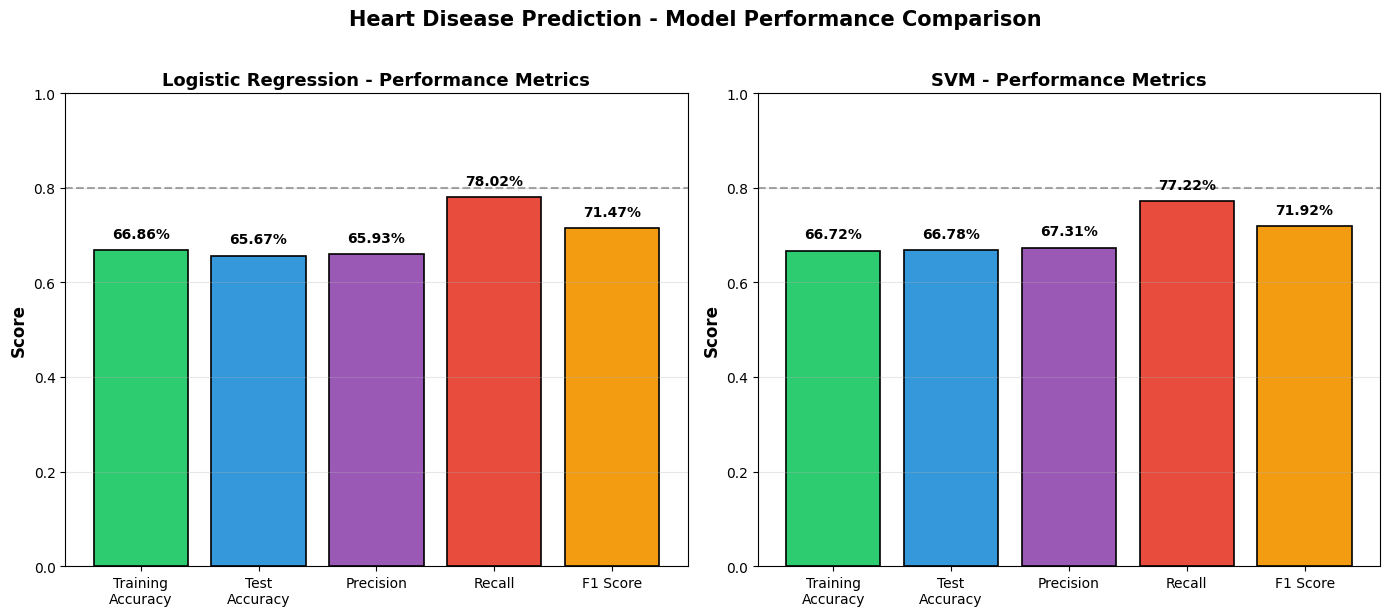

✅ Graph saved to: graphs/heart_performance_metrics.png


In [28]:
# 1. Model Comparison - Training vs Test Accuracy Bar Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression Metrics
metrics = ['Training\nAccuracy', 'Test\nAccuracy', 'Precision', 'Recall', 'F1 Score']
lr_values = [training_data_accuracy, test_data_accuracy, lr_precision, lr_recall, lr_f1]
svm_values = [training_data_accuracy_svm, test_data_accuracy_svm, svm_precision, svm_recall, svm_f1]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']

# Logistic Regression subplot
bars1 = axes[0].bar(metrics, lr_values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression - Performance Metrics', fontsize=13, fontweight='bold')
axes[0].axhline(y=0.8, color='gray', linestyle='--', alpha=0.7)
for bar, val in zip(bars1, lr_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# SVM subplot
bars2 = axes[1].bar(metrics, svm_values, color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('SVM - Performance Metrics', fontsize=13, fontweight='bold')
axes[1].axhline(y=0.8, color='gray', linestyle='--', alpha=0.7)
for bar, val in zip(bars2, svm_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Heart Disease Prediction - Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../ML/graphs/heart_performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/heart_performance_metrics.png")

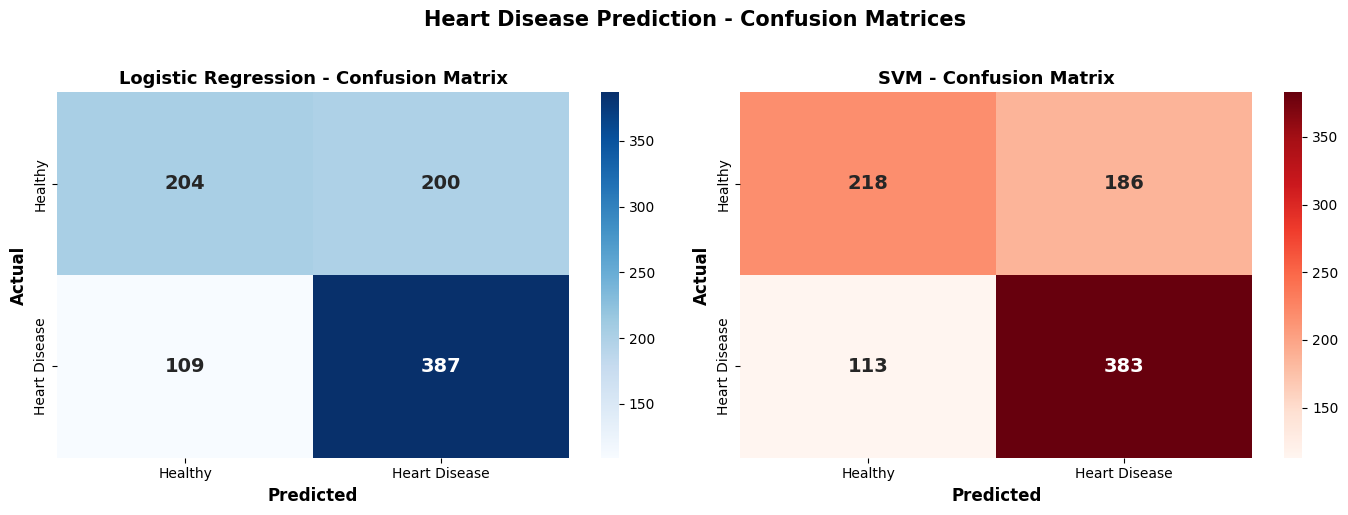

✅ Graph saved to: graphs/heart_confusion_matrices.png


In [29]:
# 2. Confusion Matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=13, fontweight='bold')

# SVM Confusion Matrix
cm_svm = confusion_matrix(Y_test, X_test_prediction_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[1], 
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1].set_title('SVM - Confusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Heart Disease Prediction - Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../ML/graphs/heart_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/heart_confusion_matrices.png")

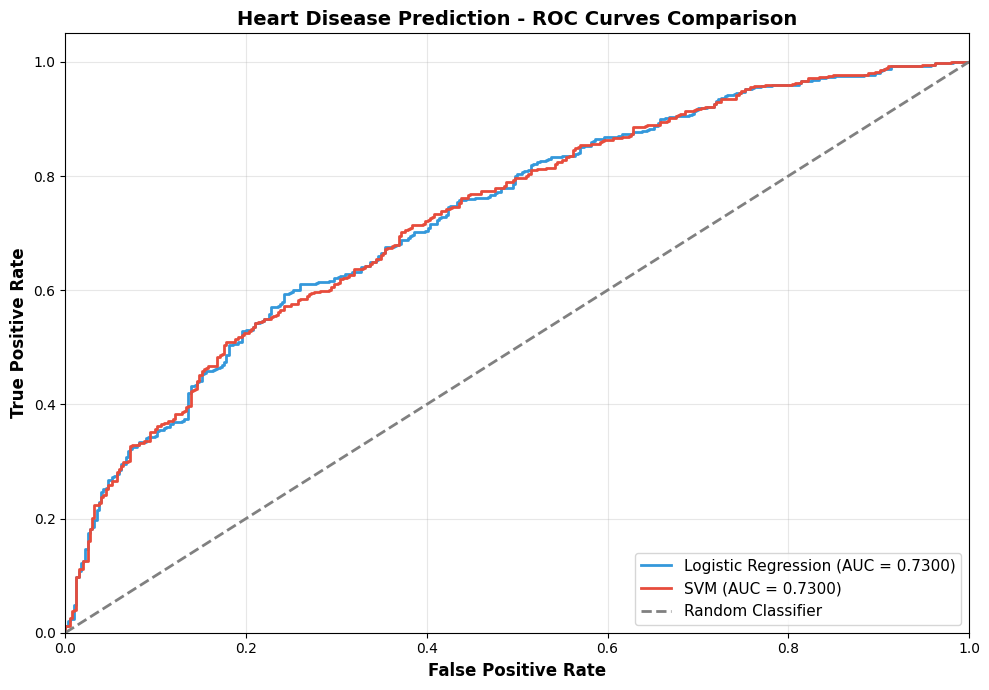

✅ Graph saved to: graphs/heart_roc_curves.png


In [30]:
# 3. ROC Curves Comparison
fig, ax = plt.subplots(figsize=(10, 7))

# Logistic Regression ROC
y_prob_lr = model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(Y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr, color='#3498db', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')

# SVM ROC
y_scores_svm = svm_model.decision_function(X_test)
fpr_svm, tpr_svm, _ = roc_curve(Y_test, y_scores_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
ax.plot(fpr_svm, tpr_svm, color='#e74c3c', lw=2, label=f'SVM (AUC = {roc_auc_svm:.4f})')

# Random classifier line
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Heart Disease Prediction - ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/heart_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/heart_roc_curves.png")

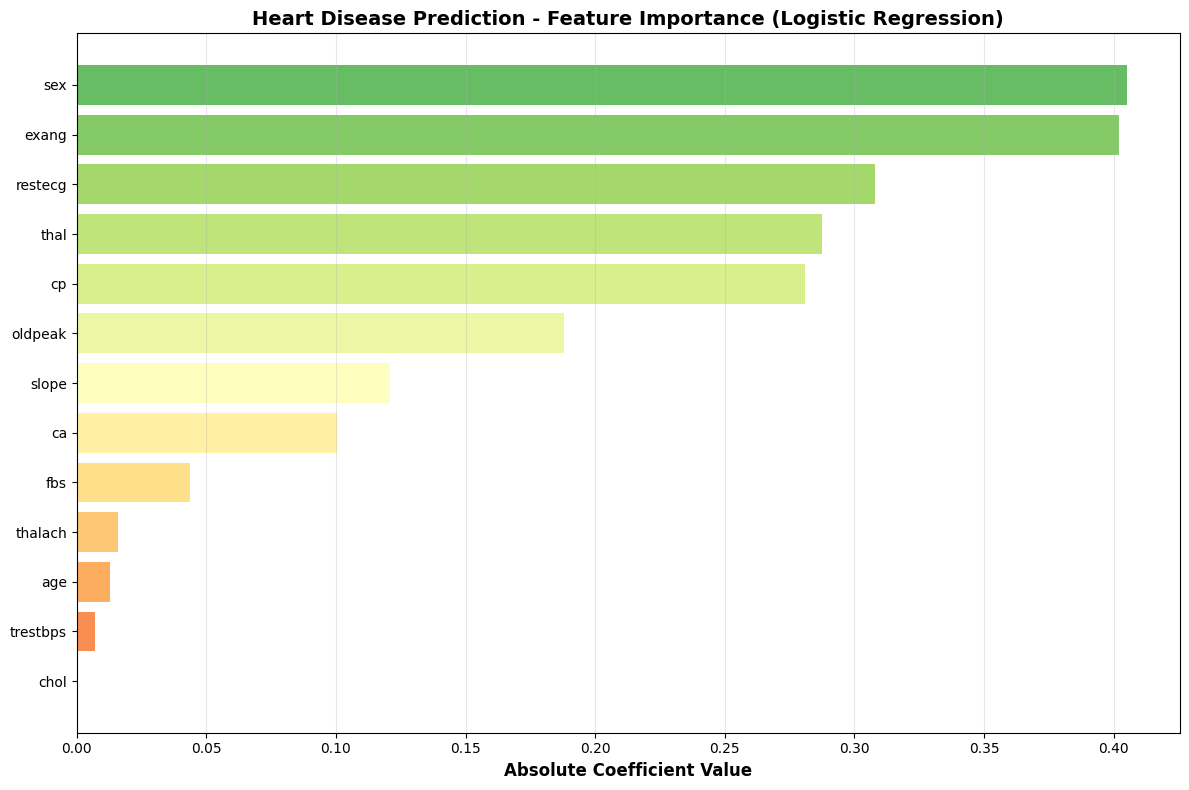

✅ Graph saved to: graphs/heart_feature_importance.png


In [31]:
# 4. Feature Importance (based on Logistic Regression coefficients)
fig, ax = plt.subplots(figsize=(12, 8))
feature_names = X.columns.tolist()
coefficients = model.coef_[0]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients)
}).sort_values('Importance', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax.set_xlabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Heart Disease Prediction - Feature Importance (Logistic Regression)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/heart_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/heart_feature_importance.png")

In [32]:
# 5. Download Heart Graphs as ZIP
import zipfile
from pathlib import Path

def create_heart_graphs_zip():
    """Create a downloadable ZIP file containing heart disease model graphs."""
    graphs_dir = Path('../ML/graphs')
    zip_path = graphs_dir / 'heart_graphs.zip'
    
    if graphs_dir.exists():
        graph_files = [f for f in graphs_dir.glob('heart_*.png')]
        
        if graph_files:
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                for graph_file in graph_files:
                    zipf.write(graph_file, graph_file.name)
            
            print(f"📦 Created ZIP archive with {len(graph_files)} heart disease graphs:")
            for gf in sorted(graph_files):
                print(f"   ✓ {gf.name}")
            print(f"\n📥 Download from: {zip_path.absolute()}")
            return str(zip_path.absolute())
        else:
            print("⚠️ No heart disease graph files found. Run visualization cells first.")
    return None

create_heart_graphs_zip()

📦 Created ZIP archive with 4 heart disease graphs:
   ✓ heart_confusion_matrices.png
   ✓ heart_feature_importance.png
   ✓ heart_performance_metrics.png
   ✓ heart_roc_curves.png

📥 Download from: c:\Users\sahil\OneDrive\Desktop\CODE\Trail\ML\..\ML\graphs\heart_graphs.zip


'c:\\Users\\sahil\\OneDrive\\Desktop\\CODE\\Trail\\ML\\..\\ML\\graphs\\heart_graphs.zip'